# PADI Image — FPR Validity Check

Validate that SI p-values are uniformly distributed under H₀.

**Protocol:**
1. Train DeepSVDD on normal patches
2. Repeat N times: generate normal images → detect false anomalies → compute SI p-value
3. Check: FPR ≈ α, ECDF ≈ diagonal, KS test passes


In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('../../..'))

import numpy as np
import torch
from padi.PADI_image.si_padi import compute_p_value_one_vs_mean
from padi.PADI_image.gen_data import prepare_synthetic_global_anomaly, SyntheticFullImageDataset
from padi.PADI_image.model import DeepSVDDOneClass
from padi.util import extract_patches_tensor, resolve_device


In [7]:
# --- CONFIGURATION ---
MODEL_FAMILY = 'deepsvdd'

DEVICE = resolve_device()
PATCH_SZ = 30
PATCH_STR = 30
IMG_SIZE_FULL = (300, 300)
REPDIM = 16
CHANNELS = (8, 16)
DELTA = 20.0
ALPHA = 0.05

model_path = f'../model/{MODEL_FAMILY}_patch_synthetic_global.pth'
print(f'Model: {MODEL_FAMILY}, Device: {DEVICE}')


Model: deepsvdd, Device: cuda


## 1. Build or Load Model

In [8]:
ModelClass = DeepSVDDOneClass

if os.path.exists(model_path):
    print(f'Loading model from {model_path}...')
    model = ModelClass.load_model(model_path, device=DEVICE)
else:
    print(f'Training {MODEL_FAMILY} from scratch...')

    # Generate training data
    train_full_ds, _, _ = prepare_synthetic_global_anomaly(
        img_size=IMG_SIZE_FULL,
        n_train=500, n_ref=500, n_test_normal=50, n_test_anomaly=50,
        delta=DELTA)

    # Extract patches from training images
    train_patches = extract_patches_tensor(train_full_ds.data, PATCH_SZ, PATCH_STR)
    n_imgs, n_per_img = train_patches.shape[:2]
    flat_patches = train_patches.view(-1, 1, PATCH_SZ, PATCH_SZ)
    train_patch_ds = torch.utils.data.TensorDataset(
        flat_patches,
        torch.zeros(len(flat_patches), dtype=torch.long),
        torch.zeros(len(flat_patches), dtype=torch.long),
        torch.arange(len(flat_patches)))

    # Create and train model
    model = ModelClass(device=DEVICE)
    model.set_network(in_channels=1, img_size=(PATCH_SZ, PATCH_SZ),
                      repdim=REPDIM, channels=CHANNELS)
    model.pretrain(train_patch_ds, train_patch_ds,
                   n_epochs=100, batch_size=64)
    model.train(train_patch_ds, n_epochs=100, batch_size=64)

    # Compute radius
    model.net.eval()
    c_tensor = torch.tensor(model.c, device=DEVICE, dtype=torch.float32)
    all_dists = []
    with torch.no_grad():
        loader = torch.utils.data.DataLoader(train_patch_ds, batch_size=64)
        for x, _, _, _ in loader:
            out = model.net(x.to(DEVICE))
            dist = torch.sum((out - c_tensor) ** 2, dim=1)
            all_dists.append(dist.cpu().numpy())
    all_dists = np.concatenate(all_dists)
    model.R_squared = float(np.quantile(all_dists, 0.99))

    os.makedirs('../model', exist_ok=True)
    model.save_model(model_path)
    print(f'Model saved to {model_path}')

print(f'R² = {model.R_squared}')


Loading model from ../model/deepsvdd_patch_synthetic_global.pth...
R² = 2.2749371601094027e-05


## 2. Collect P-values under H₀

In [9]:
# Generate reference pool ONCE
_, _, ref_full_ds = prepare_synthetic_global_anomaly(
    img_size=IMG_SIZE_FULL,
    n_train=10, n_ref=500, n_test_normal=10, n_test_anomaly=0,
    delta=DELTA)
print(f'Reference pool: {len(ref_full_ds)} normal images')

MAX_PVALUES = 500
img_shape_patch = (1, PATCH_SZ, PATCH_SZ)
d = PATCH_SZ * PATCH_SZ

list_p_value = []
failures = {"no_detection": 0, "si_failed": 0}
total_attempts = 0

while len(list_p_value) < MAX_PVALUES:
    total_attempts += 1

    # Generate fresh normal TEST data only (no anomalies)
    test_normal = SyntheticFullImageDataset(
        n_samples=50, img_size=IMG_SIZE_FULL, mode='normal')

    # Random crop position
    x = np.random.randint(IMG_SIZE_FULL[1] - PATCH_SZ + 1)
    y = np.random.randint(IMG_SIZE_FULL[0] - PATCH_SZ + 1)

    # Scan normal images for false detections
    c_tensor = torch.tensor(model.c, device=DEVICE, dtype=torch.float32)
    found = False

    for idx in range(len(test_normal)):
        img, label, _, _ = test_normal[idx]
        patch = img[:, y:y+PATCH_SZ, x:x+PATCH_SZ]

        with torch.no_grad():
            p_tensor = patch.unsqueeze(0).to(DEVICE).float()
            output = model.net(p_tensor)
            score = torch.sum((output - c_tensor) ** 2).item()

        if score <= model.R_squared:
            continue

        # False detection -> compute SI p-value using fixed ref pool
        N_REFS_SAMPLE = min(50, len(ref_full_ds))
        ref_indices = np.random.choice(len(ref_full_ds), N_REFS_SAMPLE, replace=False)
        refs = np.array([
            ref_full_ds[r][0][:, y:y+PATCH_SZ, x:x+PATCH_SZ].numpy().flatten()
            for r in ref_indices
        ])
        sigma_normalized = ref_full_ds.pixel_std_normalized
        sigma = sigma_normalized ** 2 * np.eye(d)

        p_value = compute_p_value_one_vs_mean(
            patch.numpy().flatten(), refs, sigma, model,
            model.R_squared, img_shape_patch)

        if p_value is not None:
            list_p_value.append(p_value)
            found = True
            break
        else:
            failures["si_failed"] += 1
            break

    if not found:
        failures["no_detection"] += 1

    if len(list_p_value) % 100 == 0 and len(list_p_value) > 0:
        current_fpr = np.mean(np.array(list_p_value) < ALPHA)
        print(f"  [{len(list_p_value):4d}/{MAX_PVALUES}] "
              f"FPR={current_fpr:.4f}  last_p={list_p_value[-1]:.4e}")

print(f"\nCollected {len(list_p_value)} p-values in {total_attempts} attempts")
print(f"Failures: {failures}")


Reference pool: 500 normal images


/tmp/ipykernel_25073/1349331945.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c_tensor = torch.tensor(model.c, device=DEVICE, dtype=torch.float32)


  [ 100/500] FPR=0.0600  last_p=6.2974e-01
  [ 200/500] FPR=0.0650  last_p=5.7244e-01
  [ 300/500] FPR=0.0433  last_p=5.2266e-01
  [ 400/500] FPR=0.0450  last_p=1.4369e-01
  [ 500/500] FPR=0.0380  last_p=6.1479e-01

Collected 500 p-values in 503 attempts
Failures: {'no_detection': 3, 'si_failed': 0}


## 3. Results

FPR at α=0.05: 0.0380 (expected ≈ 0.05)
KS test: statistic=0.0282, p-value=0.8120
Uniform? YES ✓
Mean p-value: 0.5114


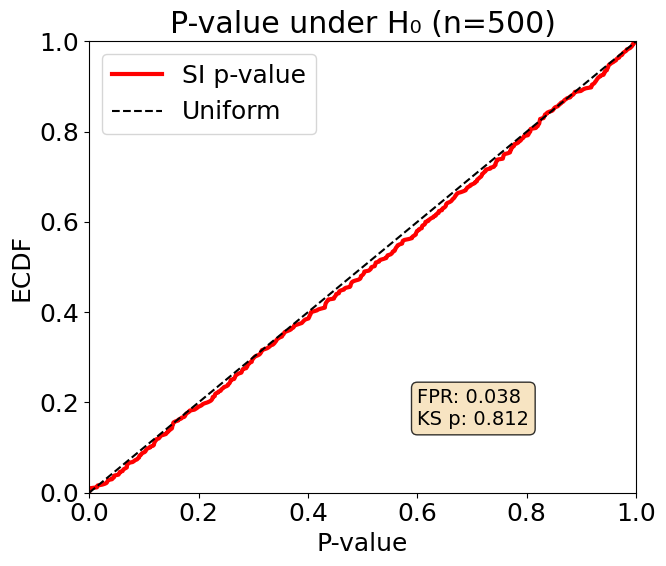

In [10]:
import scipy.stats
import matplotlib.pyplot as plt

if len(list_p_value) > 0:
    p_values = np.array(list_p_value)

    # FPR
    fpr = np.mean(p_values < ALPHA)
    ks_stat, ks_pval = scipy.stats.kstest(p_values, 'uniform')

    print(f"FPR at α={ALPHA}: {fpr:.4f} (expected ≈ {ALPHA})")
    print(f"KS test: statistic={ks_stat:.4f}, p-value={ks_pval:.4f}")
    print(f"Uniform? {'YES ✓' if ks_pval > 0.05 else 'NO ✗'}")
    print(f"Mean p-value: {np.mean(p_values):.4f}")

    # ECDF plot
    plt.rcParams.update({"font.size": 18})
    p_sorted = np.sort(p_values)
    ecdf_y = np.arange(1, len(p_sorted) + 1) / len(p_sorted)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(p_sorted, ecdf_y, 'r-', linewidth=3, label='SI p-value')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Uniform')
    ax.set_xlabel('P-value')
    ax.set_ylabel('ECDF')
    ax.set_title(f'P-value under H₀ (n={len(p_values)})')
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    ax.text(0.6, 0.15, f'FPR: {fpr:.3f}\nKS p: {ks_pval:.3f}',
            fontsize=14, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig('fpr_validity_image.png', dpi=150)
    plt.show()
else:
    print("No p-values collected — try more iterations or adjust R²")
